# UAS Kecerdasan Buatan

## Prediksi Tingkat Obesitas Berdasarkan Pola Makan dan Aktivitas Fisik Menggunakan Algoritma Decision Tree dan K-Nearest Neighbors

**Nama:** Hilma Putri Andriyani Lestari
**NIM:** 2406018
**Kelas:** Informatika A

## Import Library

**Tujuan:** memanggil seluruh library yang dibutuhkan untuk pengolahan data, visualisasi, pemodelan, evaluasi, dan penyimpanan model.

**Penjelasan:**  
Library utama yang digunakan adalah `pandas`, `numpy`, `matplotlib`, dan `scikit-learn`.  
`joblib` digunakan untuk menyimpan model setelah dilatih.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, clear_output

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Memuat Dataset

**Tujuan:** membaca file dataset CSV ke dalam DataFrame.

**Penjelasan:**  
Notebook akan mencari file dataset di beberapa lokasi umum di Google Colab.  
Jika file belum ditemukan, sistem akan meminta pengguna untuk mengunggah dataset secara manual.


In [2]:
FILE_NAME = "ObesityDataSet_raw_and_data_sinthetic.csv"

candidate_paths = [
    Path(FILE_NAME),
    Path("/content") / FILE_NAME,
    Path("data/dataset") / FILE_NAME,
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)

if dataset_path is None:
    try:
        from google.colab import files
        print("Dataset belum ditemukan. Silakan unggah file CSV.")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Tidak ada file yang diunggah.")
        uploaded_name = next(iter(uploaded))
        dataset_path = Path(uploaded_name)
    except ImportError as error:
        raise FileNotFoundError(
            f"File {FILE_NAME} belum ditemukan."
        ) from error

df_raw = pd.read_csv(dataset_path)

print("Lokasi dataset:", dataset_path)
print("Ukuran dataset:", df_raw.shape)
display(df_raw.head())

Dataset belum ditemukan. Silakan unggah file CSV.


Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv
Lokasi dataset: ObesityDataSet_raw_and_data_sinthetic.csv
Ukuran dataset: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Memeriksa Struktur Dataset

**Tujuan:** mengecek bentuk data, tipe data, missing value, dan duplikasi.

**Penjelasan:**  
Tahap ini penting untuk memastikan kualitas data sebelum dilakukan EDA dan pemodelan.


In [3]:
summary_df = pd.DataFrame({
    "Kolom": df_raw.columns,
    "Tipe Data": df_raw.dtypes.astype(str).values,
    "Missing Value": df_raw.isna().sum().values,
    "Jumlah Unik": df_raw.nunique().values,
})

print("Jumlah baris   :", df_raw.shape[0])
print("Jumlah kolom   :", df_raw.shape[1])
print("Total missing  :", int(df_raw.isna().sum().sum()))
print("Jumlah duplikat:", int(df_raw.duplicated().sum()))
display(summary_df)

Jumlah baris   : 2111
Jumlah kolom   : 17
Total missing  : 0
Jumlah duplikat: 24


,Kolom,Tipe Data,Missing Value,Jumlah Unik
0,Age,float64,0,1402
1,Gender,object,0,2
2,Height,float64,0,1574
3,Weight,float64,0,1525
4,CALC,object,0,4
5,FAVC,object,0,2
6,FCVC,float64,0,810
7,NCP,float64,0,635
8,SCC,object,0,2
9,SMOKE,object,0,2


## Distribusi Kelas Target

**Tujuan:** melihat banyaknya data pada setiap kelas obesitas.

**Interpretasi:**  
Grafik batang membantu mengetahui apakah dataset seimbang atau tidak.


,Jumlah
NObeyesdad,
Insufficient_Weight,272
Normal_Weight,287
Obesity_Type_I,351
Obesity_Type_II,297
Obesity_Type_III,324
Overweight_Level_I,290
Overweight_Level_II,290


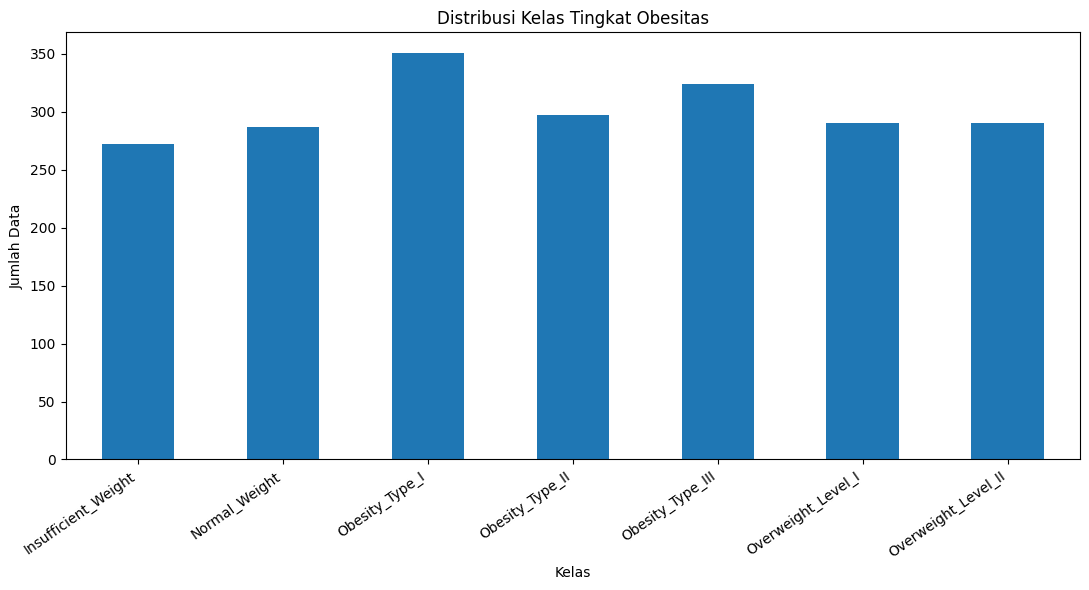

In [4]:
target_col = "NObeyesdad"
class_counts = df_raw[target_col].value_counts().sort_index()

display(class_counts.to_frame("Jumlah"))

plt.figure(figsize=(11, 6))
class_counts.plot(kind="bar")
plt.title("Distribusi Kelas Tingkat Obesitas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Persentase Kelas Target

**Tujuan:** melihat proporsi masing-masing kelas dalam bentuk pie chart.

**Interpretasi:**  
Pie chart memudahkan membaca persentase kelas secara visual.


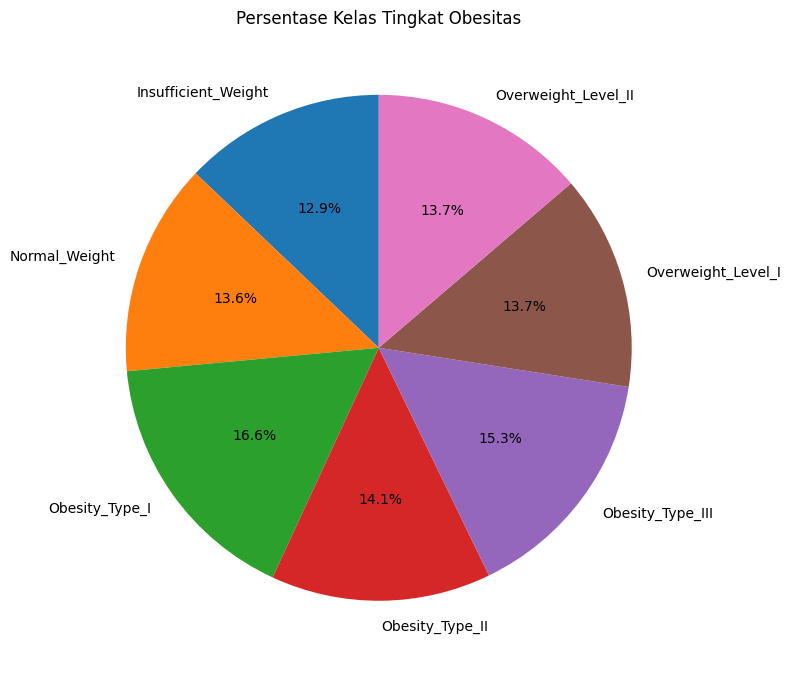

In [5]:
plt.figure(figsize=(8, 8))
class_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Persentase Kelas Tingkat Obesitas")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Histogram Usia

**Tujuan:** melihat persebaran usia responden.

**Interpretasi:**  
Histogram membantu mengetahui rentang usia yang paling banyak muncul dan apakah terdapat usia yang jauh dari kelompok utama.


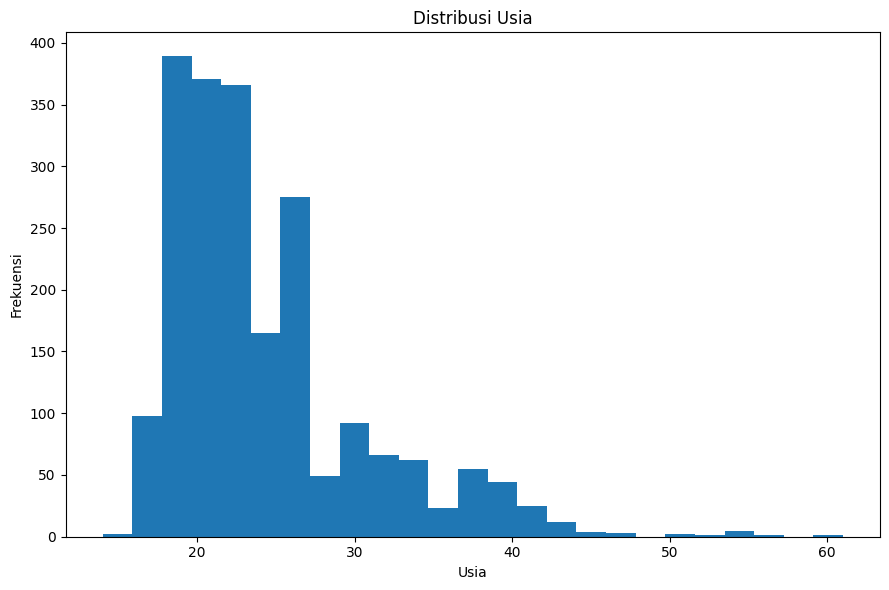

,Age
count,2111.000000
mean,24.312600
std,6.345968
min,14.000000
25%,19.947192
50%,22.777890
75%,26.000000
max,61.000000


In [6]:
plt.figure(figsize=(9, 6))
plt.hist(df_raw["Age"], bins=25)
plt.title("Distribusi Usia")
plt.xlabel("Usia")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

display(df_raw["Age"].describe().to_frame("Age"))

## Histogram Berat Badan

**Tujuan:** melihat persebaran berat badan responden.

**Interpretasi:**  
Histogram ini membantu melihat variasi berat badan dan kemungkinan nilai ekstrem.


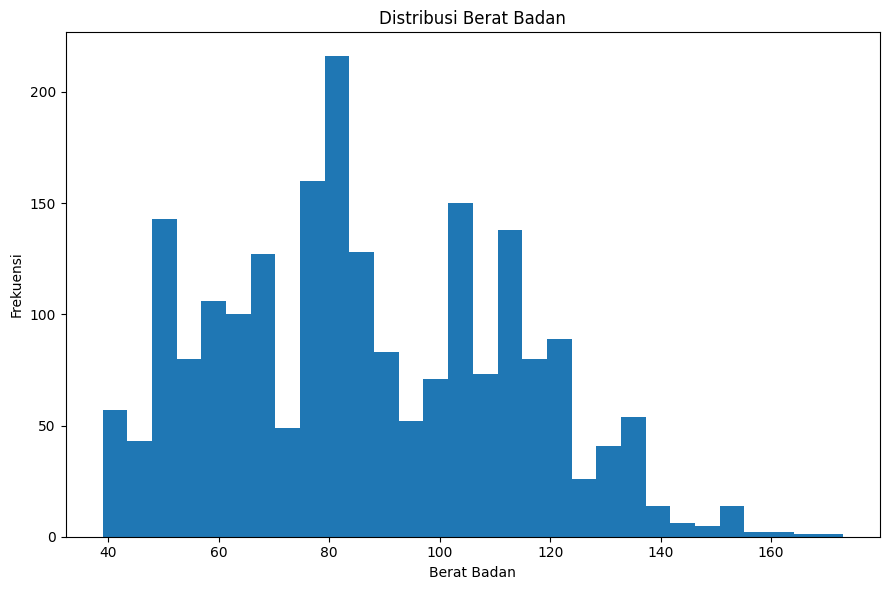

,Weight
count,2111.000000
mean,86.586058
std,26.191172
min,39.000000
25%,65.473343
50%,83.000000
75%,107.430682
max,173.000000


In [7]:
plt.figure(figsize=(9, 6))
plt.hist(df_raw["Weight"], bins=30)
plt.title("Distribusi Berat Badan")
plt.xlabel("Berat Badan")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

display(df_raw["Weight"].describe().to_frame("Weight"))

## Histogram Aktivitas Fisik

**Tujuan:** melihat persebaran frekuensi aktivitas fisik.

**Interpretasi:**  
Variabel `FAF` menggambarkan tingkat aktivitas fisik responden.


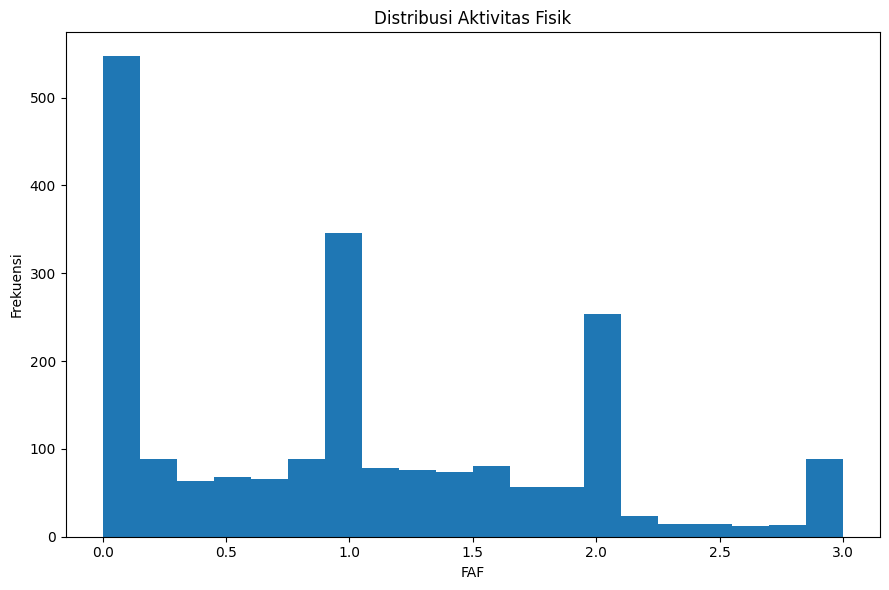

,FAF
count,2111.000000
mean,1.010298
std,0.850592
min,0.000000
25%,0.124505
50%,1.000000
75%,1.666678
max,3.000000


In [8]:
plt.figure(figsize=(9, 6))
plt.hist(df_raw["FAF"], bins=20)
plt.title("Distribusi Aktivitas Fisik")
plt.xlabel("FAF")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

display(df_raw["FAF"].describe().to_frame("FAF"))

## Boxplot Berat Badan per Kelas

**Tujuan:** membandingkan distribusi berat badan pada tiap kelas obesitas.

**Interpretasi:**  
Boxplot memudahkan melihat median, rentang data, dan kemungkinan outlier antar kelas.


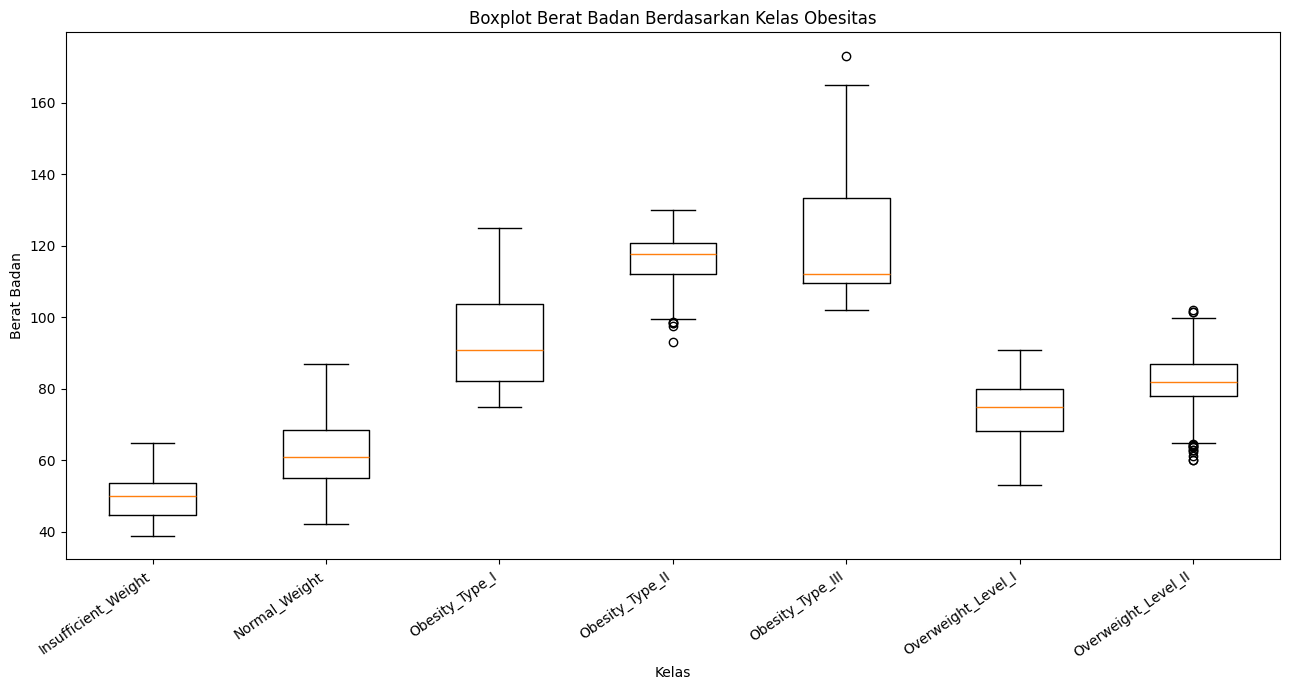

In [9]:
class_names_text = sorted(df_raw[target_col].unique())

plt.figure(figsize=(13, 7))
box_data = [
    df_raw.loc[df_raw[target_col] == cls, "Weight"].values
    for cls in class_names_text
]
plt.boxplot(box_data, tick_labels=class_names_text)
plt.title("Boxplot Berat Badan Berdasarkan Kelas Obesitas")
plt.xlabel("Kelas")
plt.ylabel("Berat Badan")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Heatmap Korelasi

**Tujuan:** melihat hubungan antarfitur numerik.

**Interpretasi:**  
Nilai korelasi membantu mengetahui fitur yang cenderung bergerak bersama, tetapi tidak menunjukkan hubungan sebab-akibat.


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000,-0.026,0.203,0.016,-0.044,-0.045,-0.145,-0.297
Height,-0.026,1.000,0.463,-0.038,0.244,0.213,0.295,0.052
Weight,0.203,0.463,1.000,0.216,0.107,0.201,-0.051,-0.072
FCVC,0.016,-0.038,0.216,1.000,0.042,0.068,0.020,-0.101
NCP,-0.044,0.244,0.107,0.042,1.000,0.057,0.130,0.036
CH2O,-0.045,0.213,0.201,0.068,0.057,1.000,0.167,0.012
FAF,-0.145,0.295,-0.051,0.020,0.130,0.167,1.000,0.059
TUE,-0.297,0.052,-0.072,-0.101,0.036,0.012,0.059,1.000


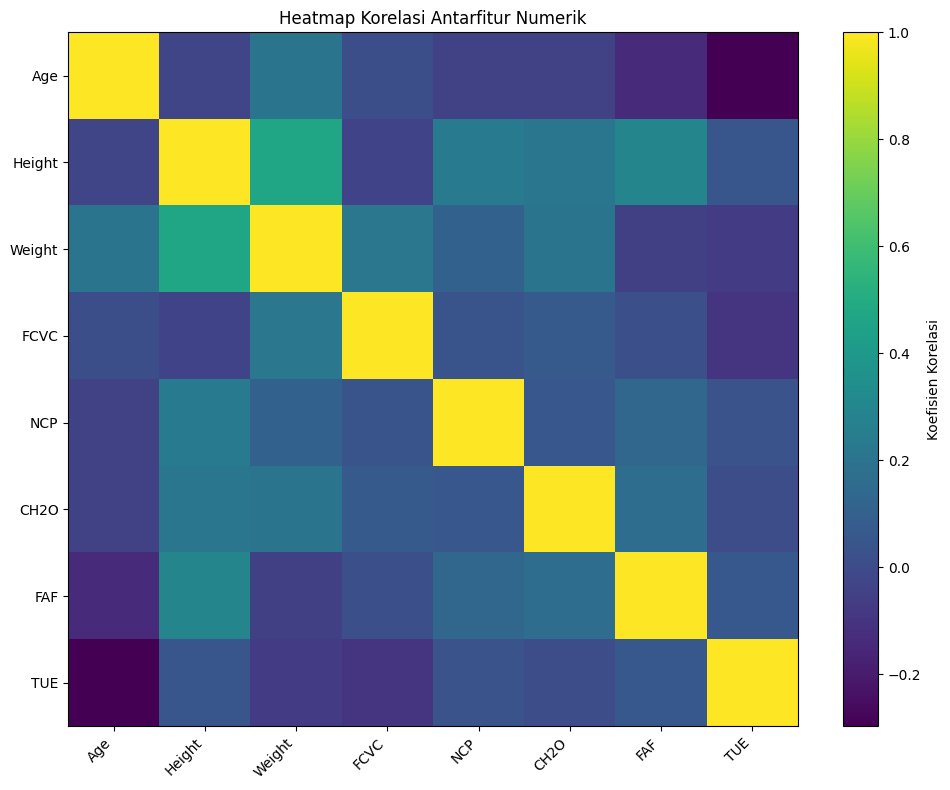

In [10]:
numeric_cols_eda = df_raw.select_dtypes(include=np.number).columns.tolist()
corr_df = df_raw[numeric_cols_eda].corr()

display(corr_df.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Koefisien Korelasi")
plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Heatmap Korelasi Antarfitur Numerik")
plt.tight_layout()
plt.show()

## Scatter Plot Tinggi dan Berat Badan

**Tujuan:** melihat pola hubungan tinggi badan dan berat badan terhadap kelas target.

**Interpretasi:**  
Scatter plot membantu melihat apakah kelas obesitas membentuk kelompok yang cukup jelas.


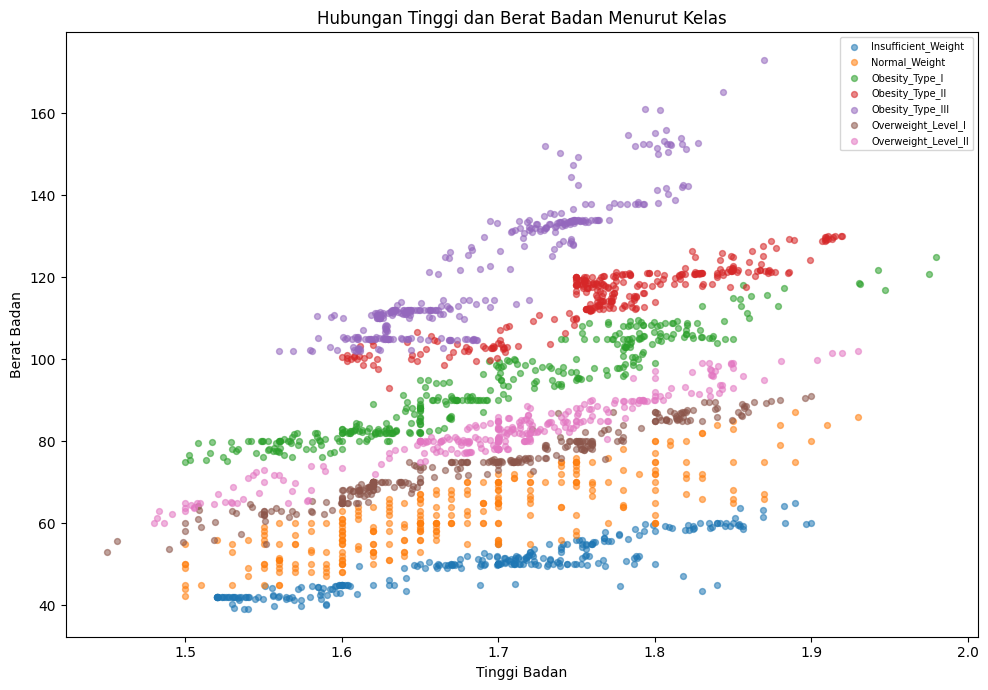

In [11]:
plt.figure(figsize=(10, 7))
for cls in class_names_text:
    part = df_raw[df_raw[target_col] == cls]
    plt.scatter(
        part["Height"],
        part["Weight"],
        alpha=0.55,
        label=cls,
        s=18,
    )

plt.title("Hubungan Tinggi dan Berat Badan Menurut Kelas")
plt.xlabel("Tinggi Badan")
plt.ylabel("Berat Badan")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Deteksi Outlier dengan IQR

**Tujuan:** mendeteksi nilai ekstrem pada fitur numerik.

**Interpretasi:**  
Metode IQR digunakan untuk melihat fitur mana yang memiliki banyak nilai ekstrem.


Baris yang memiliki minimal satu nilai ekstrem: 702


,Jumlah Outlier
NCP,579
Age,168
Weight,1
Height,1
FCVC,0
CH2O,0
FAF,0
TUE,0


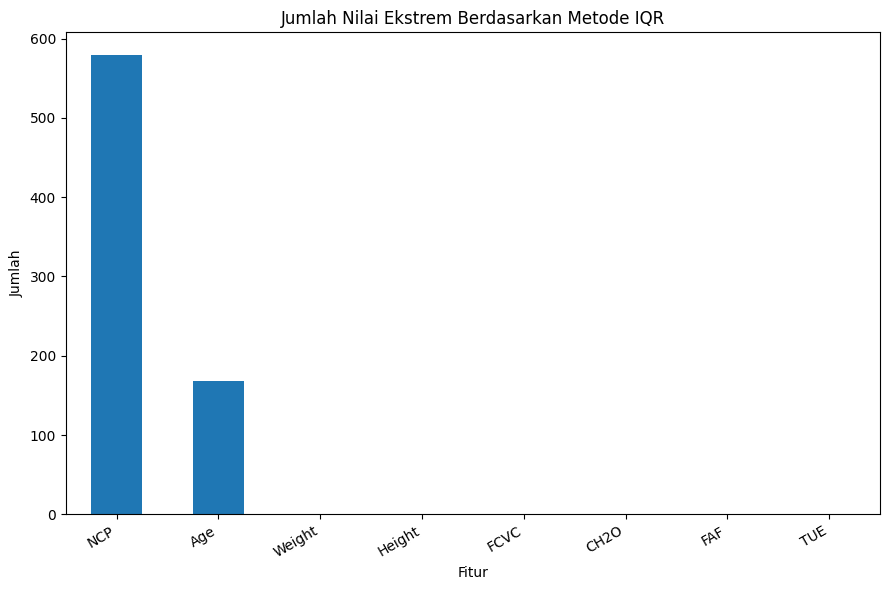

In [12]:
numeric_df = df_raw[numeric_cols_eda]

q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
iqr = q3 - q1

outlier_mask = (
    (numeric_df < (q1 - 1.5 * iqr))
    | (numeric_df > (q3 + 1.5 * iqr))
)

outlier_summary = outlier_mask.sum().sort_values(ascending=False)

print("Baris yang memiliki minimal satu nilai ekstrem:",
      int(outlier_mask.any(axis=1).sum()))
display(outlier_summary.to_frame("Jumlah Outlier"))

plt.figure(figsize=(9, 6))
outlier_summary.plot(kind="bar")
plt.title("Jumlah Nilai Ekstrem Berdasarkan Metode IQR")
plt.xlabel("Fitur")
plt.ylabel("Jumlah")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Data Preparation

**Tujuan:** membersihkan data, memisahkan fitur dan target, melakukan encoding, lalu membagi data menjadi train dan test.

**Penjelasan:**  
Data duplikat dihapus, target diubah menjadi angka dengan `LabelEncoder`, dan data dibagi 80:20.


In [13]:
df = df_raw.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[target_col])
y_text = df[target_col]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Jumlah data setelah pembersihan:", df.shape)
print("Fitur numerik   :", numeric_cols)
print("Fitur kategorik :", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Data latih:", X_train.shape)
print("Data uji  :", X_test.shape)

Jumlah data setelah pembersihan: (2087, 17)
Fitur numerik   : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Fitur kategorik : ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
Data latih: (1669, 16)
Data uji  : (418, 16)


## Membuat Preprocessing

**Tujuan:** menyiapkan proses transformasi data untuk masing-masing model.

**Penjelasan:**  
- Decision Tree: numerik diteruskan, kategorik di-One-Hot Encode.  
- KNN: numerik distandardisasi, kategorik di-One-Hot Encode.


In [14]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    [
        ("num", "passthrough", numeric_cols),
        ("cat", make_ohe(), categorical_cols),
    ]
)

knn_preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_cols),
        ("cat", make_ohe(), categorical_cols),
    ]
)

print("Preprocessing berhasil dibuat.")

Preprocessing berhasil dibuat.


## Membangun Model Decision Tree dan KNN

**Tujuan:** membuat pipeline model dan melatihnya pada data latih.

**Penjelasan:**  
Decision Tree dipilih karena mudah dijelaskan dan divisualisasikan.  
KNN dipilih sebagai pembanding kedua.


In [15]:
decision_tree = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=4,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

knn = Pipeline(
    [
        ("preprocessor", knn_preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=3,
                weights="distance",
                metric="minkowski",
                p=2,
            ),
        ),
    ]
)

models = {
    "Decision Tree": decision_tree,
    "K-Nearest Neighbors": knn,
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(model_name, "berhasil dilatih.")

Decision Tree berhasil dilatih.
K-Nearest Neighbors berhasil dilatih.


## Evaluasi Model

**Tujuan:** mengukur performa model menggunakan accuracy, precision, recall, dan F1-score.

**Penjelasan:**  
Selain itu, ditampilkan classification report dan confusion matrix untuk masing-masing model.


In [16]:
results = []
predictions = {}
confusion_matrices = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1-score": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
    })

    print("\n", "=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )

results_df = pd.DataFrame(results).sort_values(
    "F1-score", ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
}))


Decision Tree
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.92      0.95        53
      Normal_Weight       0.85      0.88      0.86        57
     Obesity_Type_I       0.94      0.93      0.94        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.85      0.85      0.85        55
Overweight_Level_II       0.90      0.97      0.93        58

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.93      0.93      0.93       418


K-Nearest Neighbors
                     precision    recall  f1-score   support

Insufficient_Weight       0.80      0.92      0.86        53
      Normal_Weight       0.76      0.39      0.51        57
     Obesity_Type_I       0.90      0.94      0.92        70
    Obesity_Type_II       0.94      1.00     

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.9330,0.9344,0.9330,0.9334
1,K-Nearest Neighbors,0.8493,0.8458,0.8493,0.8379


## Confusion Matrix

**Tujuan:** melihat detail kesalahan prediksi setiap model.

**Interpretasi:**  
Nilai diagonal menunjukkan prediksi yang benar. Nilai di luar diagonal menunjukkan kesalahan klasifikasi.


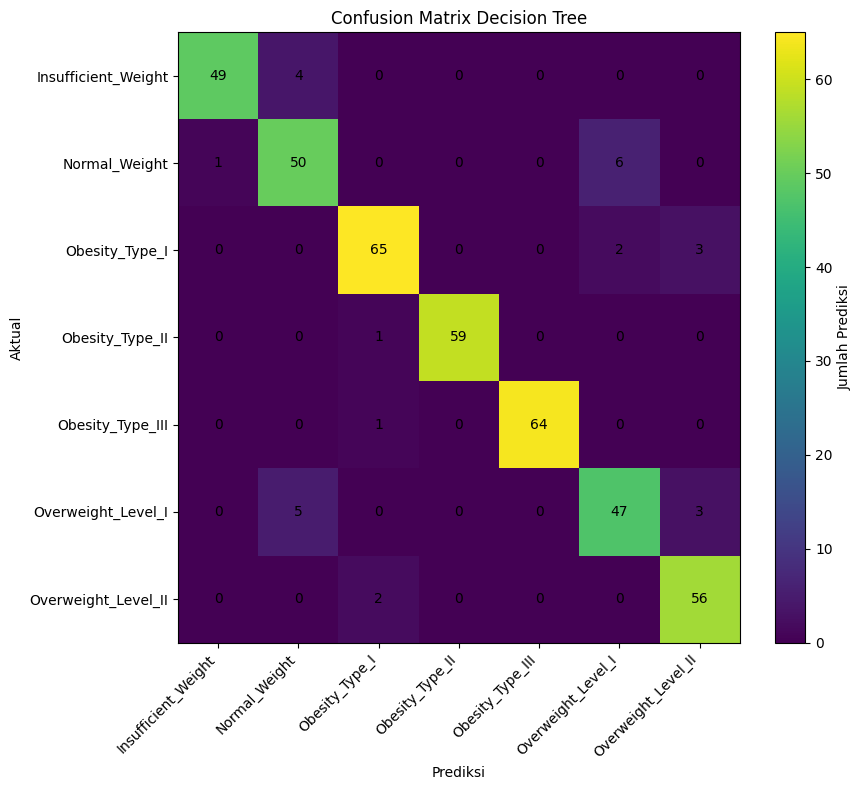

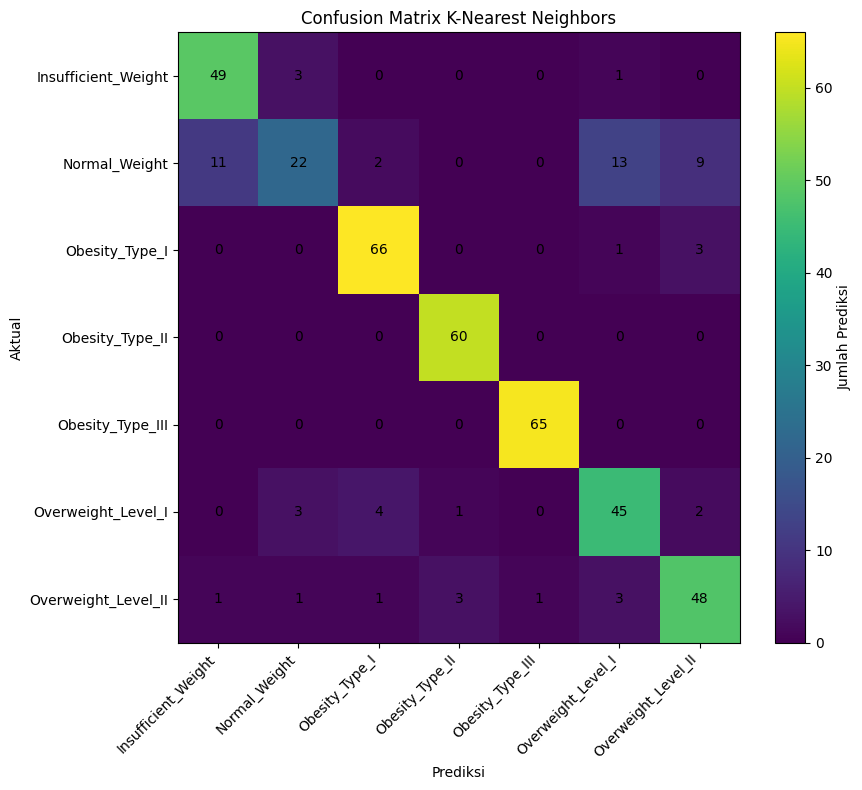

In [17]:
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(9, 8))
    plt.imshow(cm, aspect="auto")
    plt.colorbar(label="Jumlah Prediksi")
    plt.xticks(
        range(len(label_encoder.classes_)),
        label_encoder.classes_,
        rotation=45,
        ha="right",
    )
    plt.yticks(
        range(len(label_encoder.classes_)),
        label_encoder.classes_,
    )
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(f"Confusion Matrix {model_name}")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

## Grafik Perbandingan Model

**Tujuan:** membandingkan performa model secara visual.

**Interpretasi:**  
Model dengan nilai metrik lebih tinggi dianggap lebih baik pada pengujian ini.


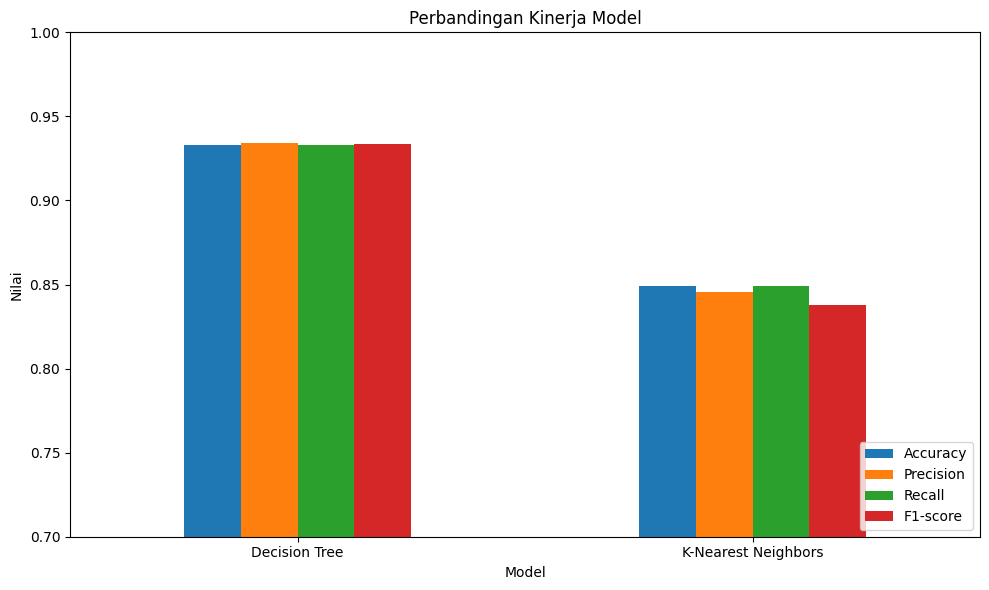

Model terbaik: Decision Tree


In [18]:
plot_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

plt.figure(figsize=(10, 6))
plot_df.plot(kind="bar", ax=plt.gca())
plt.title("Perbandingan Kinerja Model")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Model terbaik:", results_df.loc[0, "Model"])

## Visualisasi Decision Tree dan Feature Importance

**Tujuan:** menampilkan struktur Decision Tree dan fitur terpenting.

**Interpretasi:**  
Visualisasi pohon membantu menjelaskan aturan klasifikasi, sedangkan feature importance menunjukkan fitur yang paling berkontribusi pada model.


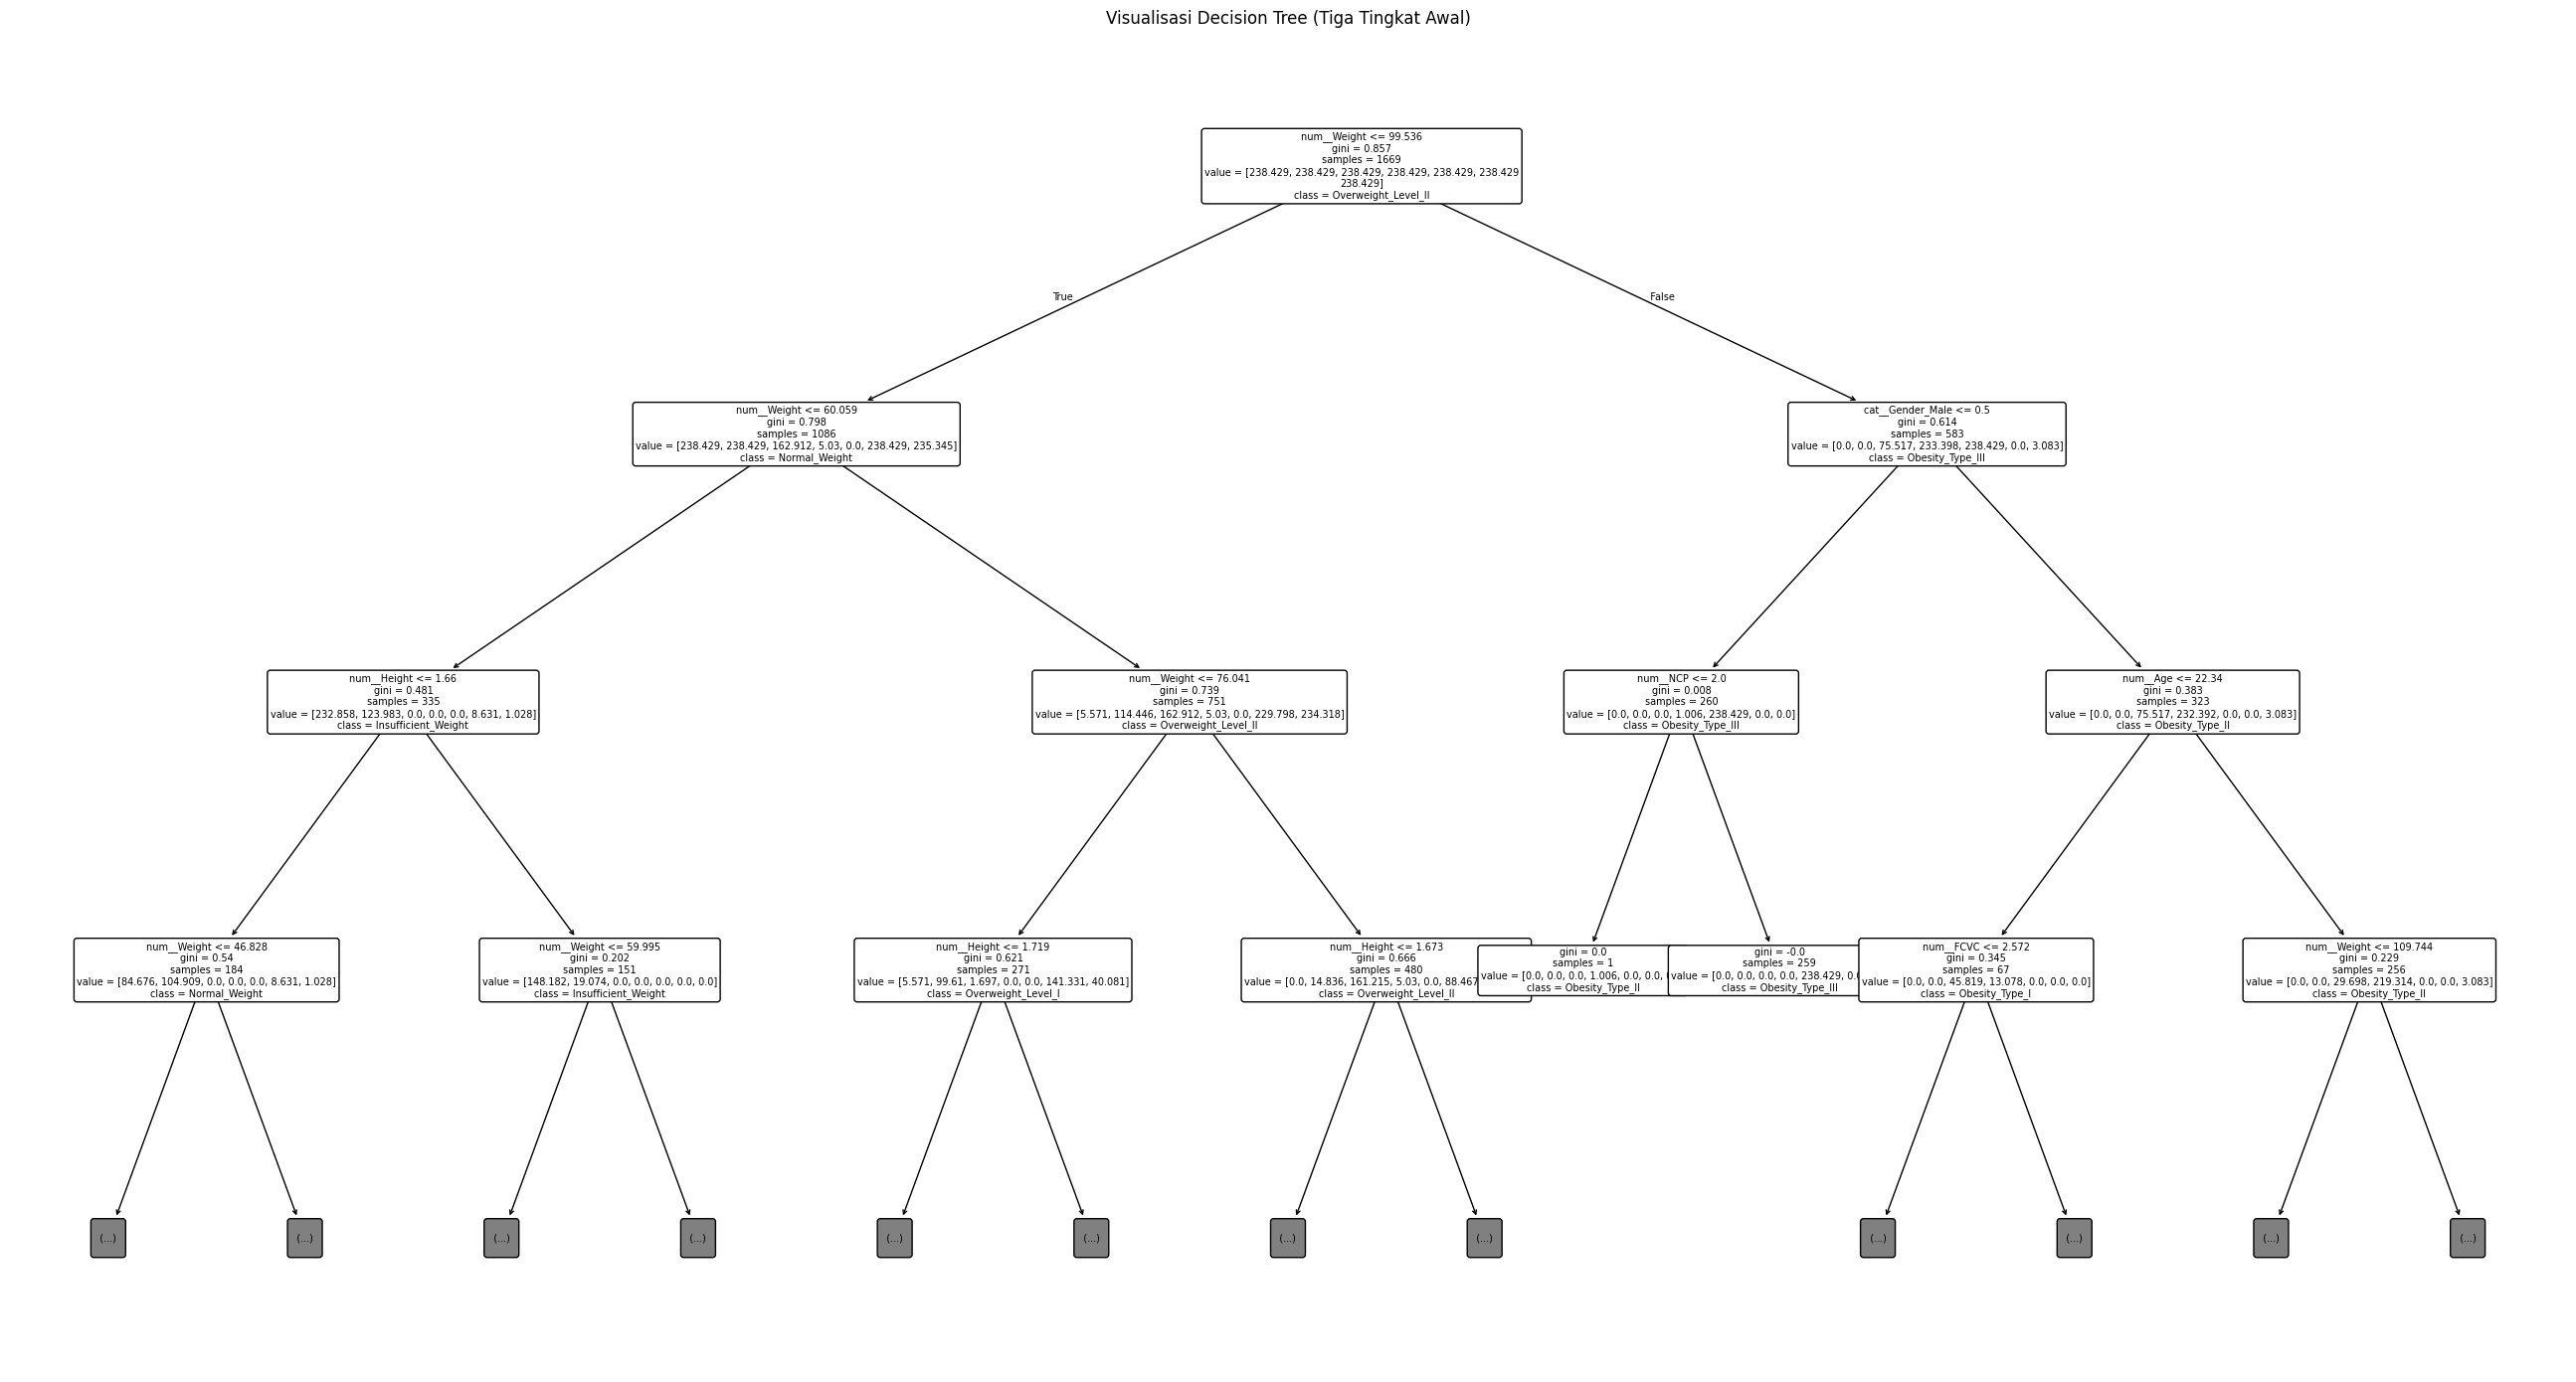

,Fitur,Importance
2,num__Weight,0.460461
1,num__Height,0.232252
9,cat__Gender_Male,0.155141
0,num__Age,0.040372
3,num__FCVC,0.024984
14,cat__FAVC_no,0.022617
13,cat__CALC_no,0.021981
23,cat__CAEC_Frequently,0.008335
4,num__NCP,0.007561
18,cat__SMOKE_no,0.004231


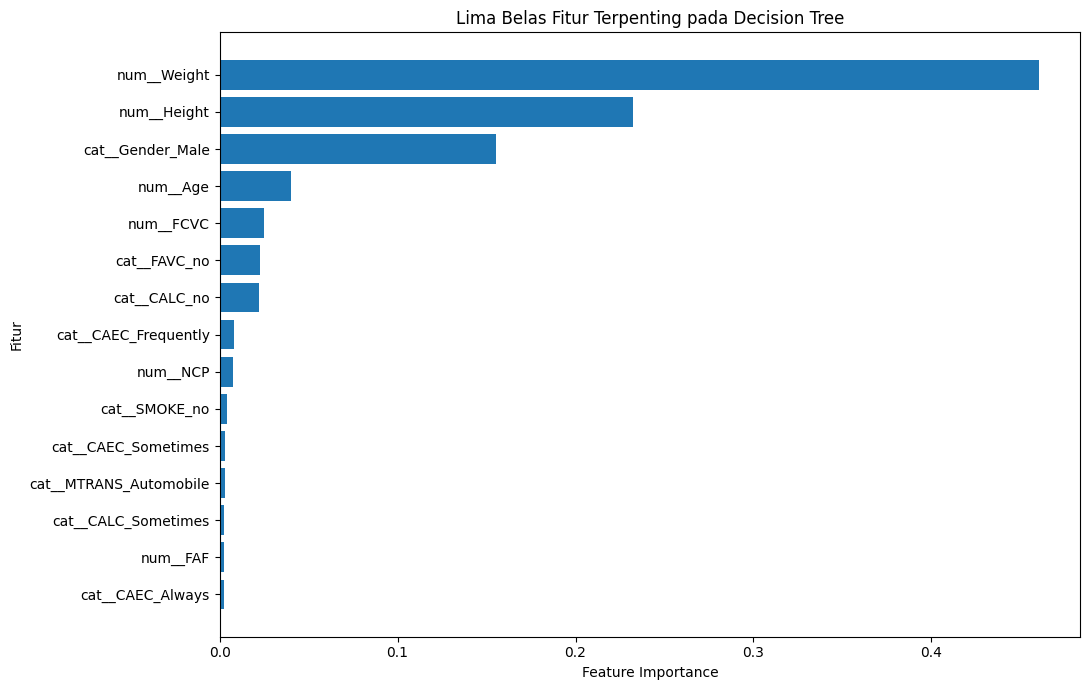

In [19]:
tree_prep = decision_tree.named_steps["preprocessor"]
tree_model = decision_tree.named_steps["classifier"]
feature_names = tree_prep.get_feature_names_out()

plt.figure(figsize=(26, 14))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    max_depth=3,
    filled=False,
    rounded=True,
    fontsize=7,
)
plt.title("Visualisasi Decision Tree (Tiga Tingkat Awal)")
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    "Fitur": feature_names,
    "Importance": tree_model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

top_importance = importance_df.head(15).sort_values("Importance")
plt.figure(figsize=(11, 7))
plt.barh(top_importance["Fitur"], top_importance["Importance"])
plt.title("Lima Belas Fitur Terpenting pada Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## Menyimpan Model dan Hasil

**Tujuan:** menyimpan model yang telah dilatih dan hasil evaluasi.

**Penjelasan:**  
Dengan menyimpan model, Anda tidak perlu melatih ulang setiap kali ingin melakukan prediksi.


In [20]:
joblib.dump(decision_tree, "decision_tree_pipeline.pkl")
joblib.dump(knn, "knn_pipeline.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
results_df.to_csv("model_comparison.csv", index=False)

print("Model dan hasil evaluasi berhasil disimpan.")

Model dan hasil evaluasi berhasil disimpan.
